In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [5]:
emb_file = '/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/data/datasets/sup_con_oof_embeddings.csv'

In [6]:
df = pd.read_csv(emb_file)
print("Shape:", df.shape)
print("Labels:", sorted(df["label"].unique()))
print("Label counts:\n", df["label"].value_counts().sort_index())
df.head()

Shape: (1980, 1540)
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Label counts:
 label
0    120
1    384
2    312
3    120
4    306
5    168
6    186
7    384
Name: count, dtype: int64


,fold,label,file,description,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_1526,emb_1527,emb_1528,emb_1529,emb_1530,emb_1531,emb_1532,emb_1533,emb_1534,emb_1535
0,1,2,https://github.com/HasinthakaPiyumal/AI-Patter...,This code implements data preprocessing patter...,0.002457,0.037354,0.025513,-0.028198,0.029541,0.026611,...,0.038330,0.025269,0.042480,-0.001320,0.017578,0.060791,0.016968,-0.001160,0.000196,0.022949
1,1,2,https://github.com/HasinthakaPiyumal/AI-Patter...,This code demonstrates AI patterns for 3D obje...,0.029785,0.011108,-0.010620,-0.004791,-0.008301,0.049072,...,0.031982,0.007416,0.017700,-0.021973,0.000858,0.027588,0.011780,-0.000751,0.008789,0.027100
2,1,2,https://github.com/HasinthakaPiyumal/AI-Patter...,This code implements data loading and preproce...,-0.009888,0.058105,0.006561,-0.025757,0.062256,0.047852,...,0.032959,0.012024,0.020752,0.037109,0.006622,0.015625,0.014526,-0.020264,0.027100,0.030029
3,1,0,https://github.com/HasinthakaPiyumal/AI-Patter...,This code demonstrates a multi-agent orchestra...,0.014832,0.013245,-0.001442,-0.011963,0.036133,0.037354,...,0.038574,-0.027100,0.054199,-0.011902,0.009766,0.024292,-0.004517,-0.001091,0.021362,-0.012512
4,1,7,https://github.com/HasinthakaPiyumal/AI-Patter...,This code implements a robust distributed Remo...,0.042969,0.043457,-0.012512,-0.012268,0.016479,0.055664,...,0.064453,0.001915,0.044434,0.011597,0.024536,0.045410,-0.007416,0.012573,-0.007538,-0.010925


In [7]:
# Extract embedding columns (emb_0 ... emb_*) and labels
emb_cols = [c for c in df.columns if c.startswith("emb_")]
X = df[emb_cols].values
y = df["label"].values
print("Embedding matrix shape:", X.shape)
print("Labels shape:", y.shape)

Embedding matrix shape: (1980, 1536)
Labels shape: (1980,)


In [8]:
# Scale embeddings (recommended before dimensionality reduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Reduce to 2D: PCA first (speed + stability), then t-SNE for visualization
n_components_pca = min(50, X_scaled.shape[0] - 1, X_scaled.shape[1])
pca = PCA(n_components=n_components_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio (first 5): {pca.explained_variance_ratio_[:5]}")
print(f"PCA total explained (first {n_components_pca}): {pca.explained_variance_ratio_.sum():.4f}")

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_pca) - 1))
X_2d = tsne.fit_transform(X_pca)
print("2D coordinates shape:", X_2d.shape)

PCA explained variance ratio (first 5): [0.01864284 0.01349266 0.01264022 0.01184915 0.01113515]
PCA total explained (first 50): 0.3081
2D coordinates shape: (1980, 2)


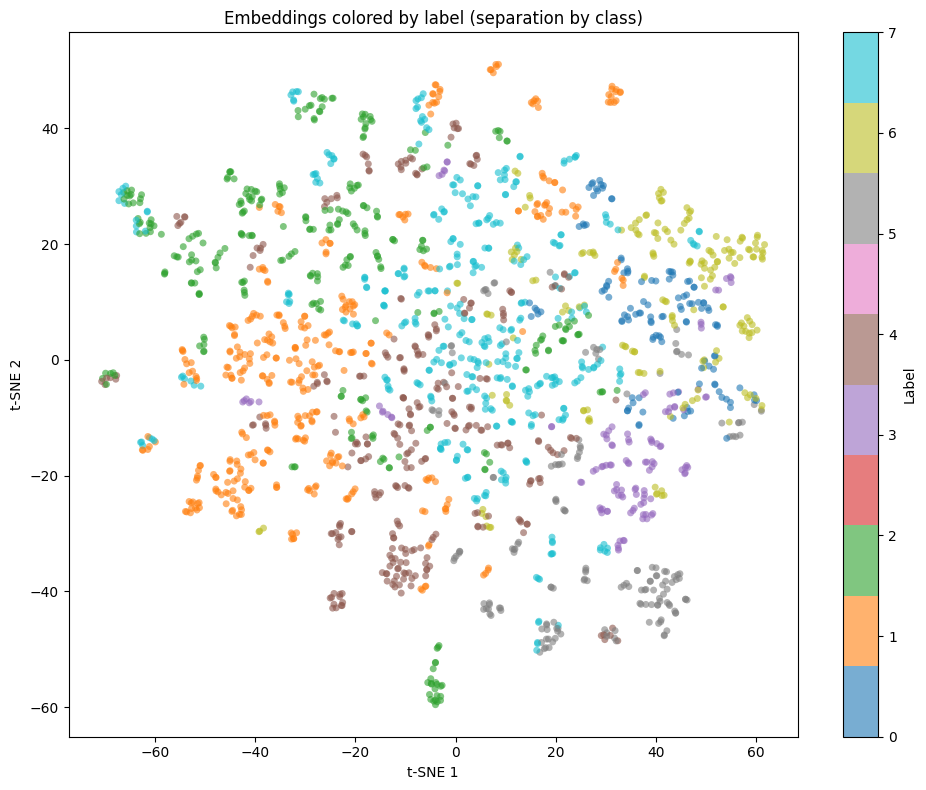

In [10]:
# Map embeddings to 2D and plot by label color
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y,
    cmap="tab10",
    alpha=0.6,
    s=25,
    edgecolors="none",
)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Embeddings colored by label (separation by class)")
cbar = plt.colorbar(scatter, ax=ax, label="Label")
plt.tight_layout()
plt.show()

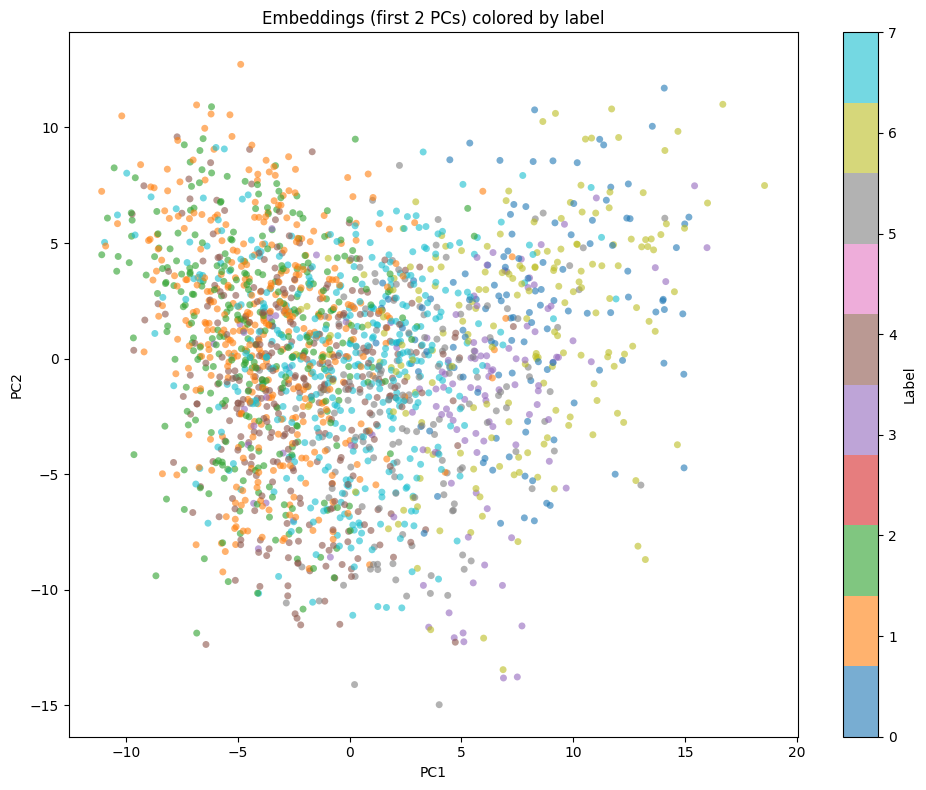

In [11]:
# Optional: PCA-only 2D view (first two components) for linear separation
X_pca_2d = X_pca[:, :2]
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="tab10",
    alpha=0.6,
    s=25,
    edgecolors="none",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Embeddings (first 2 PCs) colored by label")
plt.colorbar(scatter, ax=ax, label="Label")
plt.tight_layout()
plt.show()